# 02 — Topic Modeling: TF-IDF + K-Means

Loads the preprocessed `.npz` from the data pipeline, applies TF-IDF vectorization, uses the elbow method to select K, fits K-Means clustering, inspects top terms per cluster, and visualizes results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    accuracy_score, classification_report, confusion_matrix,
)

%matplotlib inline
sns.set_theme(style='whitegrid')

PROJECT_ROOT  = Path.cwd().parent
NPZ_PATH      = PROJECT_ROOT / 'data' / 'processed' / 'reviews.npz'
PURCHASE_CSV  = PROJECT_ROOT / 'data' / 'raw' / 'customer_purchase_data.csv'

print('NPZ path:', NPZ_PATH)

NPZ path: /Users/derrick/src/CustomerReviewTopicModeling/data/processed/reviews.npz


## 1. Load `.npz`

In [2]:
assert NPZ_PATH.exists(), f'NPZ file not found at {NPZ_PATH}. Run 01_data_pipeline.ipynb first.'

data = np.load(NPZ_PATH, allow_pickle=True)
print('Arrays in NPZ:', list(data.keys()))

reviews = data['reviews'].astype(str)
ids     = data['ids']     if 'ids'     in data else np.arange(len(reviews))
ratings = data['ratings'] if 'ratings' in data else None

print(f'Loaded {len(reviews):,} reviews')
print('Sample:', reviews[:3])

Arrays in NPZ: ['reviews', 'ids', 'product_ids']
Loaded 1,000 reviews
Sample: ['impressed quality product truly delivers'
 'happy performance exactly need'
 'regret buying quality terrible stopped working within week']


## 2. TF-IDF Vectorization

In [3]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
)

X = vectorizer.fit_transform(reviews)
print(f'TF-IDF matrix shape: {X.shape}  (reviews × features)')

TF-IDF matrix shape: (1000, 577)  (reviews × features)


## 3. Choose K — Elbow Method

Plot inertia (within-cluster sum of squares) for K = 2 to 15. Look for the elbow point.

  K= 2  inertia=961
  K= 3  inertia=948
  K= 4  inertia=936
  K= 5  inertia=920
  K= 6  inertia=911
  K= 7  inertia=896
  K= 8  inertia=890
  K= 9  inertia=877
  K=10  inertia=863
  K=11  inertia=853
  K=12  inertia=843


  K=13  inertia=832
  K=14  inertia=820
  K=15  inertia=811


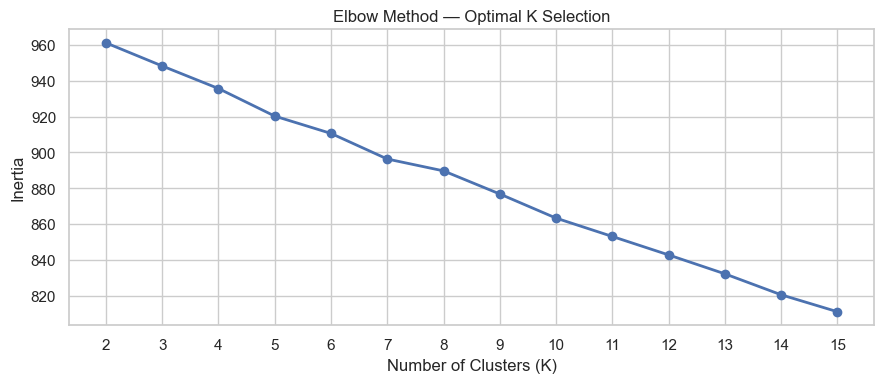

In [4]:
K_RANGE = range(2, 16)
inertias = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=5, random_state=42, max_iter=200)
    km.fit(X)
    inertias.append(km.inertia_)
    print(f'  K={k:2d}  inertia={km.inertia_:.0f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(K_RANGE), inertias, marker='o', linewidth=2)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Optimal K Selection')
ax.set_xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

## 4. Fit K-Means with Chosen K

Set `K` below based on the elbow plot above.

In [5]:
# ---- SET THIS after inspecting the elbow plot ----
K = 6
# --------------------------------------------------

kmeans = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=42, max_iter=300)
kmeans.fit(X)

labels = kmeans.labels_
print(f'Fitted K-Means with K={K}')
print('Cluster sizes:', pd.Series(labels).value_counts().sort_index().to_dict())

Fitted K-Means with K=6
Cluster sizes: {0: 35, 1: 239, 2: 101, 3: 253, 4: 229, 5: 143}


## 5. Top TF-IDF Terms per Cluster

In [6]:
N_TOP = 15
feature_names = vectorizer.get_feature_names_out()
centroids = kmeans.cluster_centers_

for cluster_id in range(K):
    top_indices = centroids[cluster_id].argsort()[-N_TOP:][::-1]
    top_terms   = [feature_names[i] for i in top_indices]
    count       = (labels == cluster_id).sum()
    print(f'Cluster {cluster_id} ({count:,} reviews):')
    print('  ', ' | '.join(top_terms))
    print()

Cluster 0 (35 reviews):
   absolutely | absolutely love | love | love product | recommending friend | friend | absolutely amazing | product absolutely | recommending | amazing recommending | expectation every | every way | amazing | product | product exceeded

Cluster 1 (239 reviews):
   product | okay | nothing | product exactly | satisfied | exactly | happy | price | expected | expectation | something | hoping | product exceeded | decent | stand

Cluster 2 (101 reviews):
   time | arrived | customer | product | customer service | product arrived | service | arrived time | long time | fantastic product | long | fantastic | product great | great | best

Cluster 3 (253 reviews):
   purchase | never | bad | using | satisfied purchase | functional | bought | money | worth | either | anything | glad bought | glad | need | never satisfied

Cluster 4 (229 reviews):
   quality | performance | impressed | product | recommend | quality performance | highly | performance product | wonderful | hi

## 6. Assign Cluster Labels to Reviews

In [7]:
df_results = pd.DataFrame({
    'id':      ids,
    'review':  reviews,
    'cluster': labels,
})

if ratings is not None:
    df_results['rating'] = ratings

print(df_results.head())
print(f'\nCluster distribution:')
print(df_results['cluster'].value_counts().sort_index())

   id                                             review  cluster
0   1           impressed quality product truly delivers        4
1   2                     happy performance exactly need        4
2   3  regret buying quality terrible stopped working...        4
3   4                serf purpose anything extraordinary        3
4   5  high quality product would buy without hesitation        4

Cluster distribution:
cluster
0     35
1    239
2    101
3    253
4    229
5    143
Name: count, dtype: int64


## 7. Visualize Clusters

### 7a. PCA Scatter Plot (2D projection)

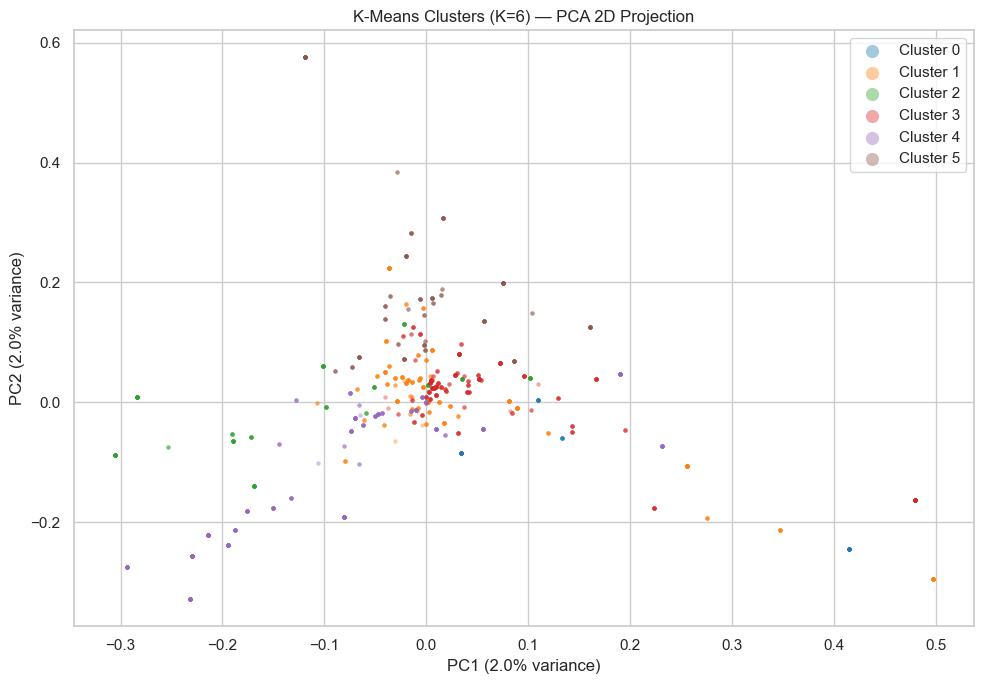

In [8]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X.toarray())

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('tab10', K)

for cluster_id in range(K):
    mask = labels == cluster_id
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        c=[palette[cluster_id]], label=f'Cluster {cluster_id}',
        alpha=0.4, s=10, linewidths=0,
    )

ax.set_title(f'K-Means Clusters (K={K}) — PCA 2D Projection')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

### 7b. Cluster Size Bar Chart

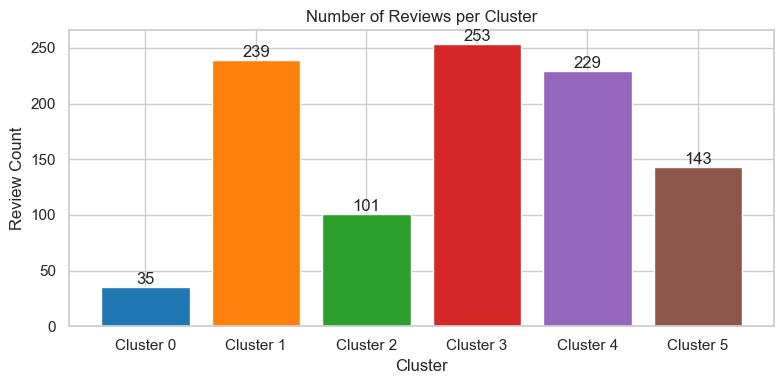

In [9]:
cluster_counts = df_results['cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [f'Cluster {i}' for i in cluster_counts.index],
    cluster_counts.values,
    color=palette,
)
ax.bar_label(bars, fmt='%d')
ax.set_title('Number of Reviews per Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Review Count')
plt.tight_layout()
plt.show()

## 8. Sample Reviews per Cluster

Qualitative check — do reviews within each cluster share a coherent theme?

In [10]:
N_SAMPLES = 5

for cluster_id in range(K):
    subset = df_results[df_results['cluster'] == cluster_id]
    sample = subset.sample(min(N_SAMPLES, len(subset)), random_state=42)
    print(f'=== Cluster {cluster_id} ({len(subset):,} reviews) ===')
    for _, row in sample.iterrows():
        # Show first 200 characters of the processed review
        print(f'  • {row["review"][:200]}')
    print()

=== Cluster 0 (35 reviews) ===
  • product absolutely amazing recommending friend
  • absolutely love product exceeded expectation every way
  • product absolutely amazing recommending friend
  • product absolutely amazing recommending friend
  • absolutely love product game changer

=== Cluster 1 (239 reviews) ===
  • product exactly wanted pleased
  • okay product issue
  • product work expected nothing special
  • everything product perfect happy
  • extremely dissatisfied product broke one use

=== Cluster 2 (101 reviews) ===
  • top notch customer service reliable product great job
  • top notch customer service reliable product great job
  • fantastic product great price worth every cent
  • best investment made long time happy purchase
  • pleased quickly arrived quality product

=== Cluster 3 (253 reviews) ===
  • mixed feeling fine expecting bit
  • extremely satisfied purchase worth every penny
  • happier purchase perfect needed
  • perfect fit need definitely order
  • usin

## 9. Cluster Evaluation Metrics

### 9a. Unsupervised Metrics

These measure cluster quality using only the feature matrix — no ground truth needed.

| Metric | Better when... |
|--------|---------------|
| Silhouette Score | Higher (max 1.0) |
| Davies-Bouldin Index | Lower (min 0.0) |
| Calinski-Harabasz Score | Higher |

In [11]:
sil  = silhouette_score(X, labels, sample_size=min(2000, X.shape[0]), random_state=42)
db   = davies_bouldin_score(X.toarray(), labels)
ch   = calinski_harabasz_score(X.toarray(), labels)

print(f'Silhouette Score      : {sil:.4f}   (higher is better, range -1 to 1)')
print(f'Davies-Bouldin Index  : {db:.4f}   (lower is better, min 0)')
print(f'Calinski-Harabasz     : {ch:.2f}  (higher is better)')

Silhouette Score      : 0.0492   (higher is better, range -1 to 1)
Davies-Bouldin Index  : 5.3337   (lower is better, min 0)
Calinski-Harabasz     : 14.02  (higher is better)


### 9b. Supervised Metrics — Ground Truth via ProductCategory

`customer_purchase_data.csv` contains `ProductCategory` (Electronics or Home Appliances) joinable to reviews via `ProductID`. Each cluster is assigned its majority category label, then accuracy, classification report, and confusion matrix are computed.

> **Note:** When K > 2, multiple clusters may map to the same category — this is expected. The confusion matrix reflects how well the unsupervised clusters separate the two real-world product categories.

Cluster → Category mapping:
  Cluster 0 (35 reviews) → Home Appliances
  Cluster 1 (239 reviews) → Home Appliances
  Cluster 2 (101 reviews) → Home Appliances
  Cluster 3 (253 reviews) → Home Appliances
  Cluster 4 (229 reviews) → Electronics
  Cluster 5 (143 reviews) → Electronics

Accuracy: 0.5250

Classification Report:
                 precision    recall  f1-score   support

    Electronics       0.53      0.40      0.46       501
Home Appliances       0.52      0.65      0.58       499

       accuracy                           0.53      1000
      macro avg       0.53      0.53      0.52      1000
   weighted avg       0.53      0.53      0.52      1000



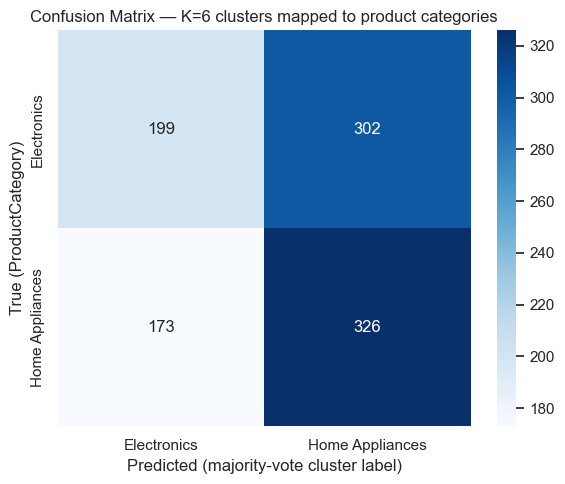

In [12]:
# Build ProductID → ProductCategory lookup (one entry per ProductID)
assert PURCHASE_CSV.exists(), f'Purchase CSV not found: {PURCHASE_CSV}'
df_purchase = pd.read_csv(PURCHASE_CSV)
category_map = df_purchase.groupby('ProductID')['ProductCategory'].first()

# Get product_ids from NPZ (saved by 01_data_pipeline.ipynb)
assert 'product_ids' in data, (
    "'product_ids' not found in NPZ. Re-run 01_data_pipeline.ipynb to regenerate the file."
)
product_ids = data['product_ids']
true_labels = np.array([category_map[pid] for pid in product_ids])

# Majority-vote mapping: assign each cluster the category of its most common member
cluster_to_category = {}
for c in range(K):
    mask = labels == c
    vals, counts = np.unique(true_labels[mask], return_counts=True)
    cluster_to_category[c] = vals[counts.argmax()]

pred_labels = np.array([cluster_to_category[c] for c in labels])

print('Cluster → Category mapping:')
for c, cat in cluster_to_category.items():
    count = (labels == c).sum()
    print(f'  Cluster {c} ({count:,} reviews) → {cat}')

print()
print(f'Accuracy: {accuracy_score(true_labels, pred_labels):.4f}')
print()
print('Classification Report:')
print(classification_report(true_labels, pred_labels))

# Confusion matrix heatmap
cm = confusion_matrix(true_labels, pred_labels, labels=sorted(category_map.unique()))
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(category_map.unique()),
    yticklabels=sorted(category_map.unique()),
    ax=ax,
)
ax.set_xlabel('Predicted (majority-vote cluster label)')
ax.set_ylabel('True (ProductCategory)')
ax.set_title(f'Confusion Matrix — K={K} clusters mapped to product categories')
plt.tight_layout()
plt.show()